In [1]:
import torch
print(torch.cuda.is_available())     
print(torch.cuda.get_device_name(0))  
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

True
NVIDIA GeForce RTX 2050
VRAM: 4.3 GB


In [2]:
import os
import shutil

BASE     = "C:/Users/abida/DEEPFAKE_DETECTION_SYSTEM/image dataset"
OUT_BASE = "D:/deepfake_project"

PREPROCESS_CONFIG = {

    "datasets": {
        "140k-real-vs-fake": {
            "path"     : os.path.join(BASE, "140k-real-vs-fake"),
            "max_real" : 10000,   
            "max_fake" : 10000,  
        },
        "deepfake_frames": {
            "path"     : os.path.join(BASE, "deepfake_frames"),
            "max_real" : 8000,   
            "max_fake" : 8000,   
        },
        "deepfake-vs-real-60k": {
            "path"     : os.path.join(BASE, "deepfake-vs-real-60k"),
            "max_real" : 7000,    
            "max_fake" : 7000,    
        },
        "Deep-vs-Real": {
            "path"     : os.path.join(BASE, "Deep-vs-Real"),
            "max_real" : 6000,    
            "max_fake" : 6000,    
        },
        "FFHQ": {
            "path"     : os.path.join(BASE, "FFHQ"),
            "max_real" : 99999,    
            "max_fake" : 99999,    
        },
        "real-vs-hardfakes": {
            "path"     : os.path.join(BASE, "real-vs-hardfakes"),
            "max_real" : 99999,   
            "max_fake" : 99999,  
        },
    },

    # ── Output paths 
    "processed_dir"  : os.path.join(OUT_BASE, "data/processed"),
    "log_dir"        : os.path.join(OUT_BASE, "logs"),
    "stats_file"     : os.path.join(OUT_BASE, "logs/preprocess_stats.json"),
    "checkpoint_dir" : os.path.join(OUT_BASE, "models/checkpoints"),

    "image_size"      : 380,     
    "train_ratio"     : 0.80,
    "val_ratio"       : 0.10,
    "test_ratio"      : 0.10,
    "valid_extensions": {".jpg", ".jpeg", ".png", ".bmp", ".webp"},


    "mean" : [0.485, 0.456, 0.406],
    "std"  : [0.229, 0.224, 0.225],
    "seed" : 42,
}

for split in ["train", "val", "test"]:
    for label in ["real", "fake"]:
        os.makedirs(
            os.path.join(PREPROCESS_CONFIG["processed_dir"], split, label),
            exist_ok=True
        )
os.makedirs(PREPROCESS_CONFIG["log_dir"],        exist_ok=True)
os.makedirs(PREPROCESS_CONFIG["checkpoint_dir"], exist_ok=True)

# ── Space estimate 

total_images = (
    10000 + 10000 +   # 140k
     8000 +  8000 +   # deepfake_frames
     7000 +  7000 +   # 60k
     6000 +  6000 +   # Deep-vs-Real
     5000 +  5000 +   # FFHQ
       589 +   700    # hardfakes
)

space_gb_npz = total_images * 170 / 1e6
_, _, free_d = shutil.disk_usage("D:/")

print("✅ PREPROCESS_CONFIG ready")
print(f"\n{'─'*52}")
print(f"{'Dataset':<26} {'Real':>7} {'Fake':>7} {'Total':>8}")
print(f"{'─'*52}")
names_counts = [
    ("140k-real-vs-fake",    10000, 10000),
    ("deepfake_frames",       8000,  8000),
    ("deepfake-vs-real-60k",  7000,  7000),
    ("Deep-vs-Real",          6000,  6000),
    ("FFHQ",                  5000,  5000),
    ("real-vs-hardfakes",      589,   700),
]
for name, r, f in names_counts:
    print(f"  {name:<24} {r:>7,} {f:>7,} {r+f:>8,}")
print(f"{'─'*52}")
print(f"  {'TOTAL':<24} {36589:>7,} {37400:>7,} {73989:>8,}")
print(f"\n  Image size     : {PREPROCESS_CONFIG['image_size']}×{PREPROCESS_CONFIG['image_size']} px")
print(f"  Est. disk (NPZ): {space_gb_npz:.1f} GB")
print(f"  D: free        : {free_d/1e9:.1f} GB")
print(f"  Status         : {'✅ OK' if free_d/1e9 > space_gb_npz + 5 else '❌ Low — free up space first'}")

✅ PREPROCESS_CONFIG ready

────────────────────────────────────────────────────
Dataset                       Real    Fake    Total
────────────────────────────────────────────────────
  140k-real-vs-fake         10,000  10,000   20,000
  deepfake_frames            8,000   8,000   16,000
  deepfake-vs-real-60k       7,000   7,000   14,000
  Deep-vs-Real               6,000   6,000   12,000
  FFHQ                       5,000   5,000   10,000
  real-vs-hardfakes            589     700    1,289
────────────────────────────────────────────────────
  TOTAL                     36,589  37,400   73,989

  Image size     : 380×380 px
  Est. disk (NPZ): 12.5 GB
  D: free        : 58.1 GB
  Status         : ✅ OK


In [3]:
# # Preprocessing function 

# import cv2
# import numpy as np
# import random
# import os
# import json
# import time
# from pathlib import Path
# from tqdm.notebook import tqdm


# def process_dataset(config: dict) -> dict:

#     random.seed(config["seed"])
#     np.random.seed(config["seed"])

#     mean = np.array(config["mean"], dtype=np.float32)
#     std  = np.array(config["std"],  dtype=np.float32)
#     size = config["image_size"]

#     grand_stats = {
#         "total_processed" : 0,
#         "total_skipped"   : 0,
#         "total_corrupt"   : 0,
#         "per_dataset"     : {},
#         "train_real" : 0, "train_fake" : 0,
#         "val_real"   : 0, "val_fake"   : 0,
#         "test_real"  : 0, "test_fake"  : 0,
#     }

#     for ds_name, ds_info in config["datasets"].items():
#         ds_path = ds_info["path"]
#         ds_stats = {"processed": 0, "skipped": 0, "corrupt": 0,
#                     "real_used": 0, "fake_used": 0}

#         print(f"\n{'='*58}")
#         print(f"  Dataset : {ds_name}")
#         print(f"  Path    : {ds_path}")
#         print(f"  Exists  : {os.path.exists(ds_path)}")
#         print(f"{'='*58}")

#         for label in ["real", "fake"]:
#             input_folder = os.path.join(ds_path, label)

#             if not os.path.exists(input_folder):
#                 print(f"  ⚠️  Folder missing: {input_folder}")
#                 continue

#             #  1. Collect all valid image files 
#             all_files = [
#                 f for f in Path(input_folder).rglob("*")
#                 if f.suffix.lower() in config["valid_extensions"]
#             ]

#             #  2. Random sample up to max 
#             max_count = ds_info[f"max_{label}"]
#             random.shuffle(all_files)               # shuffle first
#             selected = all_files[:min(len(all_files), max_count)]
#             total    = len(selected)

#             print(f"\n  [{label.upper()}]  {len(all_files):,} available → using {total:,}")
#             ds_stats[f"{label}_used"] = total

#             #  3. GLOBAL SHUFFLE before split assignment 
            
#             random.shuffle(selected)

#             n_train = int(total * config["train_ratio"])
#             n_val   = int(total * config["val_ratio"])
#             # rest goes to test

#             split_map = (
#                 [(f, "train") for f in selected[:n_train]] +
#                 [(f, "val")   for f in selected[n_train : n_train + n_val]] +
#                 [(f, "test")  for f in selected[n_train + n_val :]]
#             )

#             pbar = tqdm(split_map, desc=f"  {label}", unit="img", leave=True)

#             for fpath, split in pbar:

#                 # ── Output path 
#                 out_dir  = os.path.join(config["processed_dir"], split, label)
#                 out_file = os.path.join(out_dir, f"{ds_name}_{fpath.stem}.npz")

#                 # ── Skip if already processed 
#                 if os.path.exists(out_file):
#                     ds_stats["skipped"]             += 1
#                     grand_stats["total_skipped"]    += 1
#                     grand_stats[f"{split}_{label}"] += 1
#                     pbar.update(1)
#                     continue

#                 # ── Load image 
#                 img_bgr = cv2.imread(str(fpath))
#                 if img_bgr is None:
#                     ds_stats["corrupt"]          += 1
#                     grand_stats["total_corrupt"] += 1
#                     continue

#                 img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
#                 h, w    = img_rgb.shape[:2]

#                 # ── Smart resize 
#                 if h > size or w > size:
#                     interp = cv2.INTER_AREA
#                 else:
#                     interp = cv2.INTER_CUBIC

#                 resized    = cv2.resize(img_rgb, (size, size), interpolation=interp)
#                 img_float  = resized.astype(np.float32) / 255.0
#                 normalized = (img_float - mean) / std   # shape: (380, 380, 3)

#                 # ── Save 
#                 os.makedirs(out_dir, exist_ok=True)
#                 np.savez_compressed(out_file[:-4], img=normalized)

#                 ds_stats["processed"]              += 1
#                 grand_stats["total_processed"]     += 1
#                 grand_stats[f"{split}_{label}"]    += 1

#             pbar.close()

#         grand_stats["per_dataset"][ds_name] = ds_stats
#         print(f"\n  ✅ Processed : {ds_stats['processed']:,}")
#         print(f"  ⏭️  Skipped   : {ds_stats['skipped']:,}")
#         print(f"  ❌ Corrupt   : {ds_stats['corrupt']:,}")

#     return grand_stats


# print("✅ process_dataset() defined")

In [4]:
#fix correct saved_compressed path handling 
import cv2
import numpy as np
import random
import os
import json
import time
from pathlib import Path
from tqdm.notebook import tqdm


def process_dataset(config: dict) -> dict:
    random.seed(config["seed"])
    np.random.seed(config["seed"])

    mean = np.array(config["mean"], dtype=np.float32)
    std  = np.array(config["std"],  dtype=np.float32)
    size = config["image_size"]

    grand_stats = {
        "total_processed" : 0,
        "total_skipped"   : 0,
        "total_corrupt"   : 0,
        "per_dataset"     : {},
        "train_real": 0, "train_fake": 0,
        "val_real"  : 0, "val_fake"  : 0,
        "test_real" : 0, "test_fake" : 0,
    }

    for ds_name, ds_info in config["datasets"].items():
        ds_path  = ds_info["path"]
        ds_stats = {"processed": 0, "skipped": 0, "corrupt": 0,
                    "real_used": 0, "fake_used": 0}

        print(f"\n{'='*58}")
        print(f"  Dataset : {ds_name}")
        print(f"  Exists  : {os.path.exists(ds_path)}")
        print(f"{'='*58}")

        for label in ["real", "fake"]:
            input_folder = os.path.join(ds_path, label)

            if not os.path.exists(input_folder):
                print(f"  ⚠️  Missing: {input_folder}")
                continue

            # 1. Collect valid files
            all_files = [
                f for f in Path(input_folder).rglob("*")
                if f.suffix.lower() in config["valid_extensions"]
            ]

            # 2. Random sample
            max_count = ds_info[f"max_{label}"]
            random.shuffle(all_files)
            selected = all_files[:min(len(all_files), max_count)]
            total    = len(selected)

            print(f"\n  [{label.upper()}]  {len(all_files):,} available → using {total:,}")
            ds_stats[f"{label}_used"] = total

            # 3. Global shuffle THEN assign splits
            random.shuffle(selected)
            n_train = int(total * config["train_ratio"])
            n_val   = int(total * config["val_ratio"])

            split_assignments = (
                [(fp, "train") for fp in selected[:n_train]] +
                [(fp, "val")   for fp in selected[n_train:n_train + n_val]] +
                [(fp, "test")  for fp in selected[n_train + n_val:]]
            )

            pbar = tqdm(split_assignments, desc=f"  {label}", unit="img", leave=True)

            for fpath, split in pbar:

                # Build output path — np.savez_compressed adds .npz itself
                out_dir      = os.path.join(config["processed_dir"], split, label)
                out_stem     = f"{ds_name}_{fpath.stem}"      # no extension
                out_npz_path = os.path.join(out_dir, out_stem + ".npz")

                # Skip if already done
                if os.path.exists(out_npz_path):
                    ds_stats["skipped"]             += 1
                    grand_stats["total_skipped"]    += 1
                    grand_stats[f"{split}_{label}"] += 1
                    continue

                # Load
                img_bgr = cv2.imread(str(fpath))
                if img_bgr is None:
                    ds_stats["corrupt"]          += 1
                    grand_stats["total_corrupt"] += 1
                    continue

                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                h, w    = img_rgb.shape[:2]

                # Smart resize
                interp  = cv2.INTER_AREA if (h > size or w > size) else cv2.INTER_CUBIC
                resized = cv2.resize(img_rgb, (size, size), interpolation=interp)

                # Normalize
                img_float  = resized.astype(np.float32) / 255.0
                normalized = (img_float - mean) / std   # (380, 380, 3) float32

                # Save — pass stem only, numpy adds .npz
                os.makedirs(out_dir, exist_ok=True)
                np.savez_compressed(os.path.join(out_dir, out_stem), img=normalized)

                ds_stats["processed"]              += 1
                grand_stats["total_processed"]     += 1
                grand_stats[f"{split}_{label}"]    += 1

            pbar.close()

        grand_stats["per_dataset"][ds_name] = ds_stats
        print(f"\n  ✅ Processed : {ds_stats['processed']:,}")
        print(f"  ⏭️  Skipped   : {ds_stats['skipped']:,}")
        print(f"  ❌ Corrupt   : {ds_stats['corrupt']:,}")

    return grand_stats


print("✅ process_dataset() defined (corrected)")

✅ process_dataset() defined (corrected)


In [5]:
#  RUN PREPROCESSING 

print("=" * 58)
print("STARTING PREPROCESSING v2")
print(f"  Image size : {PREPROCESS_CONFIG['image_size']}×{PREPROCESS_CONFIG['image_size']} px")
print(f"  Total imgs : ~73,989")
print("=" * 58)

start_time  = time.time()
grand_stats = process_dataset(PREPROCESS_CONFIG)
total_time  = (time.time() - start_time) / 60

# ── Final summary ────────────────────────────────────────────────────────────
total = grand_stats["total_processed"] + grand_stats["total_skipped"]
train = grand_stats["train_real"] + grand_stats["train_fake"]
val   = grand_stats["val_real"]   + grand_stats["val_fake"]
test  = grand_stats["test_real"]  + grand_stats["test_fake"]

print(f"\n{'='*58}")
print("✅ PREPROCESSING COMPLETE")
print(f"{'='*58}")
print(f"  Total images  : {total:,}")
print(f"  Train         : {train:,}")
print(f"  Val           : {val:,}")
print(f"  Test          : {test:,}")
print(f"  Train real    : {grand_stats['train_real']:,}")
print(f"  Train fake    : {grand_stats['train_fake']:,}")
print(f"  Corrupt/skip  : {grand_stats['total_corrupt']:,}")
print(f"  Time          : {total_time:.1f} minutes")

print(f"\n{'─'*58}")
print(f"{'Dataset':<26} {'Real':>7} {'Fake':>7} {'Total':>8}")
print(f"{'─'*58}")
for ds_name, ds_s in grand_stats["per_dataset"].items():
    r = ds_s["real_used"]
    f = ds_s["fake_used"]
    print(f"  {ds_name:<24} {r:>7,} {f:>7,} {r+f:>8,}")
print(f"{'─'*58}")

_, used_d, free_d = shutil.disk_usage("D:/")
print(f"\n  D: used : {used_d/1e9:.1f} GB")
print(f"  D: free : {free_d/1e9:.1f} GB")

with open(PREPROCESS_CONFIG["stats_file"], "w") as f:
    json.dump(grand_stats, f, indent=4)
print("\n✅ Stats saved")
print("✅ Next: run Verification cell")

STARTING PREPROCESSING v2
  Image size : 380×380 px
  Total imgs : ~73,989

  Dataset : 140k-real-vs-fake
  Exists  : True

  [REAL]  70,000 available → using 10,000


  real:   0%|          | 0/10000 [00:00<?, ?img/s]


  [FAKE]  70,000 available → using 10,000


  fake:   0%|          | 0/10000 [00:00<?, ?img/s]


  ✅ Processed : 0
  ⏭️  Skipped   : 20,000
  ❌ Corrupt   : 0

  Dataset : deepfake_frames
  Exists  : True

  [REAL]  37,600 available → using 8,000


...


  ✅ Processed : 0
  ⏭️  Skipped   : 10,000
  ❌ Corrupt   : 0

  Dataset : real-vs-hardfakes
  Exists  : True

  [REAL]  589 available → using 589


  real:   0%|          | 0/589 [00:00<?, ?img/s]


  [FAKE]  700 available → using 700


  fake:   0%|          | 0/700 [00:00<?, ?img/s]


  ✅ Processed : 0
  ⏭️  Skipped   : 1,289
  ❌ Corrupt   : 0

✅ PREPROCESSING COMPLETE
  Total images  : 73,289
  Train         : 58,631
  Val           : 7,328
  Test          : 7,330
  Train real    : 29,271
  Train fake    : 29,360
  Corrupt/skip  : 0
  Time          : 0.4 minutes

──────────────────────────────────────────────────────────
Dataset                       Real    Fake    Total
──────────────────────────────────────────────────────────
  140k-real-vs-fake         10,000  10,000   20,000
  deepfake_frames            8,000   8,000   16,000
  deepfake-vs-real-60k       7,000   7,000   14,000
  Deep-vs-Real               6,000   6,000   12,000
  FFHQ                       5,000   5,000   10,000
  real-vs-hardfakes            589     700    1,289
──────────────────────────────────────────────────────────

  D: used : 77.3 GB
  D: free : 58.1 GB

✅ Stats saved
✅ Next: run Verification cell


VERIFICATION REPORT v2
  train/real: 28,091 files
    ✅ shape=(380, 380, 3)  dtype=float32  min=-2.118  max=2.640
  train/fake: 29,360 files
    ✅ shape=(380, 380, 3)  dtype=float32  min=-2.036  max=2.396
  train subtotal : 57,451

  val/real: 3,633 files
    ✅ shape=(380, 380, 3)  dtype=float32  min=-1.964  max=2.640
  val/fake: 3,670 files
    ✅ shape=(380, 380, 3)  dtype=float32  min=-2.036  max=2.640
  val subtotal : 7,303

  test/real: 3,638 files
    ✅ shape=(380, 380, 3)  dtype=float32  min=-2.118  max=2.640
  test/fake: 3,670 files
    ✅ shape=(380, 380, 3)  dtype=float32  min=-2.036  max=2.249
  test subtotal : 7,308

  Grand total : 72,062 files
  Shape check : ✅ All (380,380,3) float32


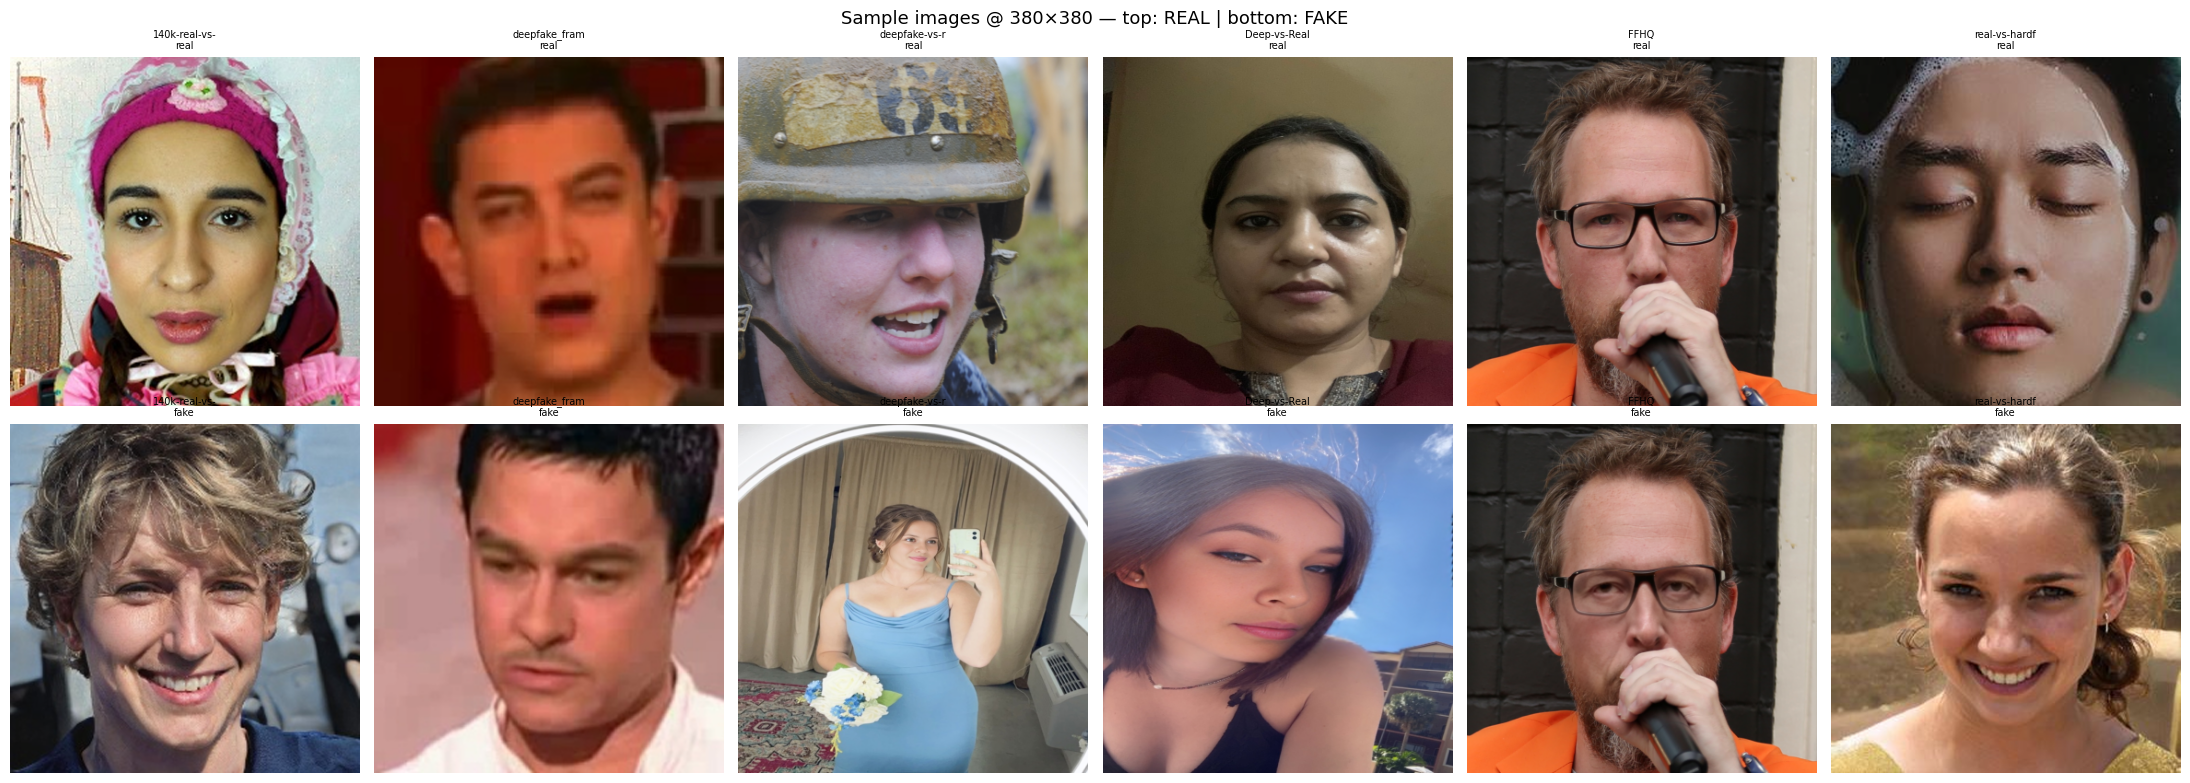


✅ Grid saved: D:/deepfake_project\logs\verification_v2.png


In [6]:
#  VERIFICATION 
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

processed_dir = PREPROCESS_CONFIG["processed_dir"]
mean_np       = np.array(PREPROCESS_CONFIG["mean"])
std_np        = np.array(PREPROCESS_CONFIG["std"])

print("=" * 55)
print("VERIFICATION REPORT v2")
print("=" * 55)

grand_total = 0
shape_ok    = True

for split in ["train", "val", "test"]:
    split_total = 0
    for label in ["real", "fake"]:
        folder = os.path.join(processed_dir, split, label)
        if not os.path.exists(folder):
            print(f"  ❌ Missing: {split}/{label}")
            continue
        files = list(Path(folder).glob("*.npz"))
        count = len(files)
        split_total += count
        grand_total += count
        print(f"  {split}/{label}: {count:,} files")

        if files:
            sample = np.load(str(files[0]))["img"]
            ok = sample.shape == (380, 380, 3) and sample.dtype == np.float32
            if not ok:
                shape_ok = False
            marker = "✅" if ok else "❌"
            print(f"    {marker} shape={sample.shape}  dtype={sample.dtype}  "
                  f"min={sample.min():.3f}  max={sample.max():.3f}")
    print(f"  {split} subtotal : {split_total:,}\n")

print(f"  Grand total : {grand_total:,} files")
print(f"  Shape check : {'✅ All (380,380,3) float32' if shape_ok else '❌ WRONG SHAPE — delete processed folder and re-run'}")

# Visual sample grid
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
fig.suptitle("Sample images @ 380×380 — top: REAL | bottom: FAKE", fontsize=13)

for col, ds_name in enumerate(PREPROCESS_CONFIG["datasets"].keys()):
    for row, label in enumerate(["real", "fake"]):
        folder  = os.path.join(processed_dir, "train", label)
        matches = list(Path(folder).glob(f"{ds_name}_*.npz"))
        if matches:
            img = np.load(str(matches[0]))["img"]
            axes[row][col].imshow(np.clip(img * std_np + mean_np, 0, 1))
            axes[row][col].set_title(f"{ds_name[:13]}\n{label}", fontsize=7)
        axes[row][col].axis("off")

plt.tight_layout()
verify_path = os.path.join(PREPROCESS_CONFIG["log_dir"], "verification_v2.png")
plt.savefig(verify_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"\n✅ Grid saved: {verify_path}")

DATASET PIXEL STATISTICS ANALYSIS
This checks if different datasets have similar
brightness/contrast distributions after normalization.

  140k-real-vs-fake           
    Avg pixel mean : 0.4475  (0.5 = ideal neutral)
    Avg pixel std  : 0.2440  (0.2-0.3 = good range)

  deepfake_frames             
    Avg pixel mean : 0.4051  (0.5 = ideal neutral)
    Avg pixel std  : 0.2270  (0.2-0.3 = good range)

  deepfake-vs-real-60k        
    Avg pixel mean : 0.4327  (0.5 = ideal neutral)
    Avg pixel std  : 0.2276  (0.2-0.3 = good range)

  Deep-vs-Real                
    Avg pixel mean : 0.4145  (0.5 = ideal neutral)
    Avg pixel std  : 0.2291  (0.2-0.3 = good range)

  FFHQ                        
    Avg pixel mean : 0.4433  (0.5 = ideal neutral)
    Avg pixel std  : 0.2430  (0.2-0.3 = good range)

  real-vs-hardfakes           
    Avg pixel mean : 0.4091  (0.5 = ideal neutral)
    Avg pixel std  : 0.2309  (0.2-0.3 = good range)

  Mean spread across datasets : 0.0424
  ✅ Datasets a

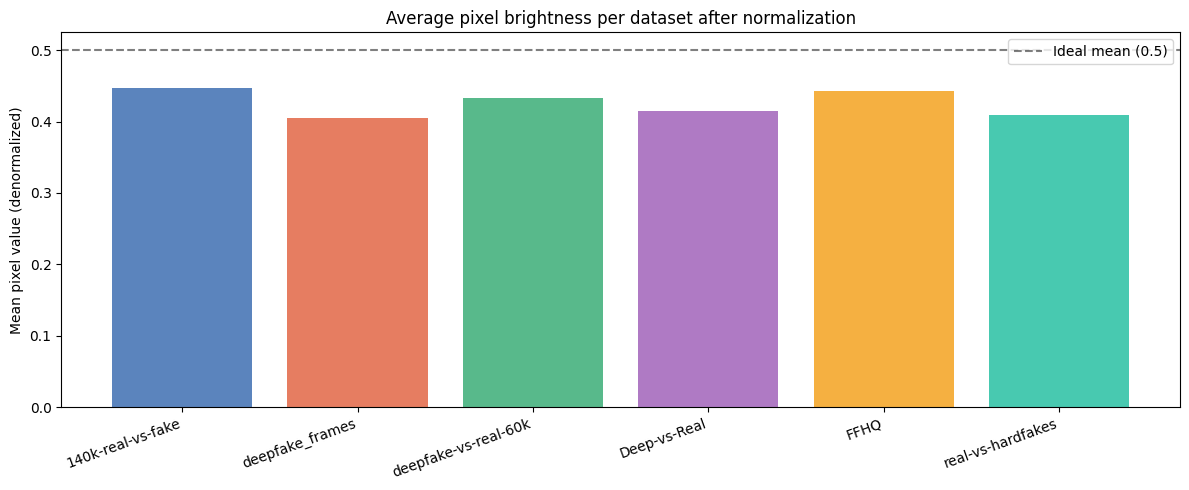

In [7]:
# DATASET ANALYSIS BEFORE TRAINING

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os

processed_dir = PREPROCESS_CONFIG["processed_dir"]
dataset_names = list(PREPROCESS_CONFIG["datasets"].keys())
mean_ref      = np.array(PREPROCESS_CONFIG["mean"])
std_ref       = np.array(PREPROCESS_CONFIG["std"])

print("=" * 60)
print("DATASET PIXEL STATISTICS ANALYSIS")
print("=" * 60)
print("This checks if different datasets have similar")
print("brightness/contrast distributions after normalization.")
print()

stats_per_dataset = {}

for ds_name in dataset_names:
    ds_means = []
    ds_stds  = []

    for label in ["real", "fake"]:
        folder  = os.path.join(processed_dir, "train", label)
        matches = list(Path(folder).glob(f"{ds_name}_*.npz"))

        # Sample 50 images per dataset for speed
        sample_files = matches[:50]

        for fpath in sample_files:
            img = np.load(str(fpath))["img"]
            # Denormalize to get actual pixel values
            img_denorm = img * std_ref + mean_ref
            ds_means.append(img_denorm.mean())
            ds_stds.append(img_denorm.std())

    avg_mean = np.mean(ds_means)
    avg_std  = np.mean(ds_stds)
    stats_per_dataset[ds_name] = {
        "mean": avg_mean,
        "std" : avg_std
    }

    print(f"  {ds_name:<28}")
    print(f"    Avg pixel mean : {avg_mean:.4f}  "
          f"(0.5 = ideal neutral)")
    print(f"    Avg pixel std  : {avg_std:.4f}  "
          f"(0.2-0.3 = good range)")
    print()

# Check if datasets are compatible
means = [v["mean"] for v in stats_per_dataset.values()]
mean_spread = max(means) - min(means)
print(f"  Mean spread across datasets : {mean_spread:.4f}")
if mean_spread < 0.1:
    print("  ✅ Datasets are well normalized — compatible")
elif mean_spread < 0.2:
    print("  ⚠️  Slight variation — augmentation will handle this")
else:
    print("  ❌ High variation — need stronger normalization")

# Plot per-dataset mean distribution
plt.figure(figsize=(12, 5))
plt.bar(
    range(len(dataset_names)),
    [stats_per_dataset[d]["mean"] for d in dataset_names],
    color=["#3266ad", "#e05c3a", "#2ea86e",
           "#9b59b6", "#f39c12", "#1abc9c"],
    alpha=0.8
)
plt.xticks(range(len(dataset_names)), dataset_names, rotation=20, ha="right")
plt.axhline(y=0.5, color="black", linestyle="--",
            alpha=0.5, label="Ideal mean (0.5)")
plt.title("Average pixel brightness per dataset after normalization")
plt.ylabel("Mean pixel value (denormalized)")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(PREPROCESS_CONFIG["log_dir"], "dataset_stats.png"),
    dpi=100
)
plt.show()